#### **프로젝트 개요**
## 부산 15분 아동돌봄 생활권 구축: 들락날락 중심 허브-위성형 방과후 돌봄 연계 모델

#### 돌봄 수요 및 공급 지도를 만들고, E2SFCA 기반 접근성을 분석합니다.
* 수요자: 초등학생 인구, 만 7~13세

  (중학생은 스스로 보호 능력이 있고, 영유아는 시설까지 스스로 접근하기 어려워 제외)
* 임계거리: 750m (이 거리 안에 있으면 이용 가능하다고 보는 기준)
* 거리 계산: 도로망 네트워크 거리 기준
* E2SFCA 계산
  - 1단계: 시설별 수요 대비 공급비 계산. `시설 j의 공급비 = 1 / 750m 안의 가중 아동 인구`
  - 2단계: 격자별 접근성 계산. `격자 i의 접근성 = 주변 시설들의 공급비 합`
  - 거리 가중치는 가우시안 함수 사용(거리가 멀어질수록 가중치 낮춤)
* 최종 행정동 접근성 = 해당 행정동 안에 포함된 100m 격자 접근성의 산술평균



In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 폰트 설정 사용하는 환경에 따라 수정하시면 됩니다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

Matplotlib is building the font cache; this may take a moment.


# 초등학생 인구 100m 격자 지도

In [3]:
# 인구 100m 격자 데이터 불러오기

gdf = gpd.read_file("data/busan_100m_population_5179.gpkg")

# 인구값 컬럼
pop_col = "val"

# 인구값 숫자형 변환
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce")

# 좌표계 확인
print("좌표계:", gdf.crs)
print("컬럼 목록:", gdf.columns.tolist())
print(gdf[[pop_col]].describe())

좌표계: EPSG:5179
컬럼 목록: ['gid', 'val', 'pop_class', 'geometry']
                val
count  10825.000000
mean      13.008776
std       23.154212
min        0.000000
25%        0.000000
50%        6.000000
75%       17.000000
max      483.000000


In [4]:
# =========================
# 3. QGIS SLD 스타일 정보
# =========================

bins = [-np.inf, 7, 11, 16, 22, 27, 37, np.inf]

labels = [
    "7 이하",
    "7 - 11 이하",
    "11 - 16 이하",
    "16 - 22 이하",
    "22 - 27 이하",
    "27 - 37 이하",
    "37 이상"
]

colors = {
    "7 이하": "#FFF5EB",
    "7 - 11 이하": "#FEE6CE",
    "11 - 16 이하": "#FDD0A2",
    "16 - 22 이하": "#FDAE6B",
    "22 - 27 이하": "#FD8D3C",
    "27 - 37 이하": "#F16913",
    "37 이상": "#CC4704"
}

# 인구 구간 생성
gdf["pop_class"] = pd.cut(
    gdf[pop_col],
    bins=bins,
    labels=labels,
    right=True
)

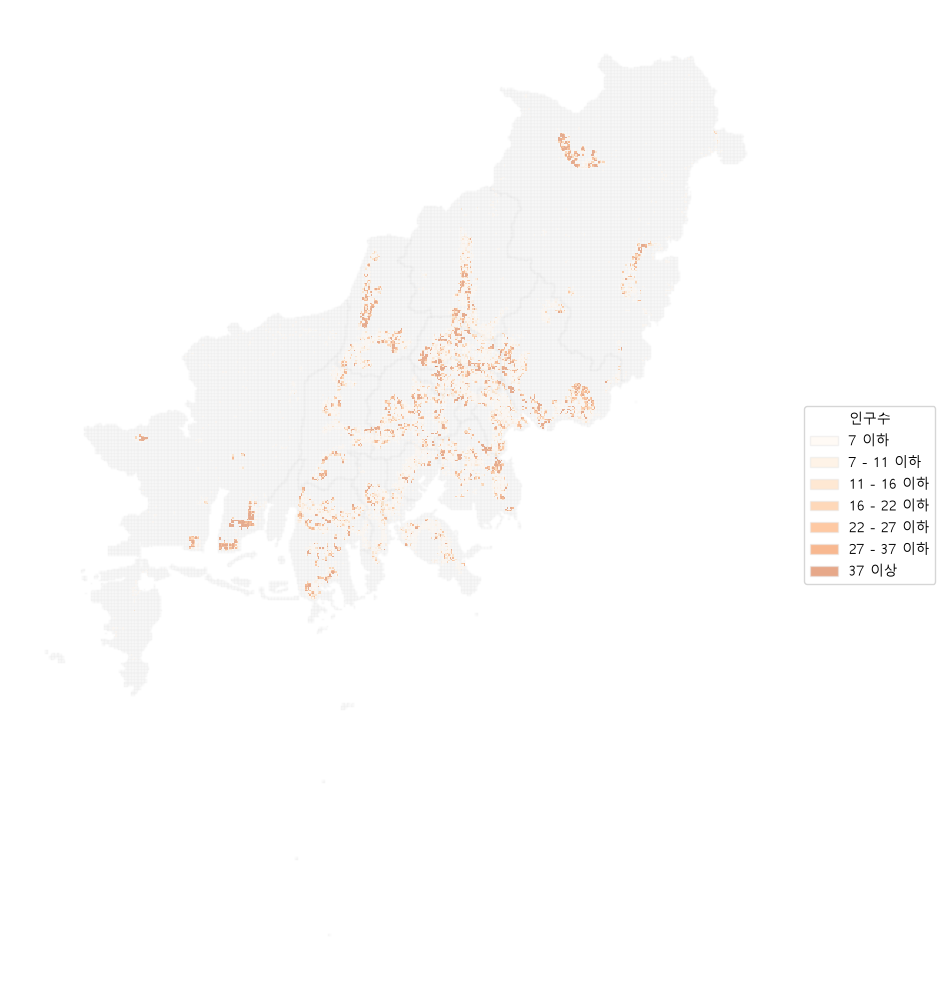

In [5]:

fig, ax = plt.subplots(figsize=(10, 10))

# 결측값 / 통계 없음
gdf[gdf["pop_class"].isna()].plot(
    ax=ax,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1
)

# 인구 구간별 색상 적용
for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.47
        )

# 범례 생성
legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.47,
        label=label
    )
    for label in labels
]

ax.legend(
    handles=legend_handles,
    title="인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_axis_off()
plt.tight_layout()
#fig.savefig("초등학생인구지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 초등학생 인구 100m 격자 히트맵

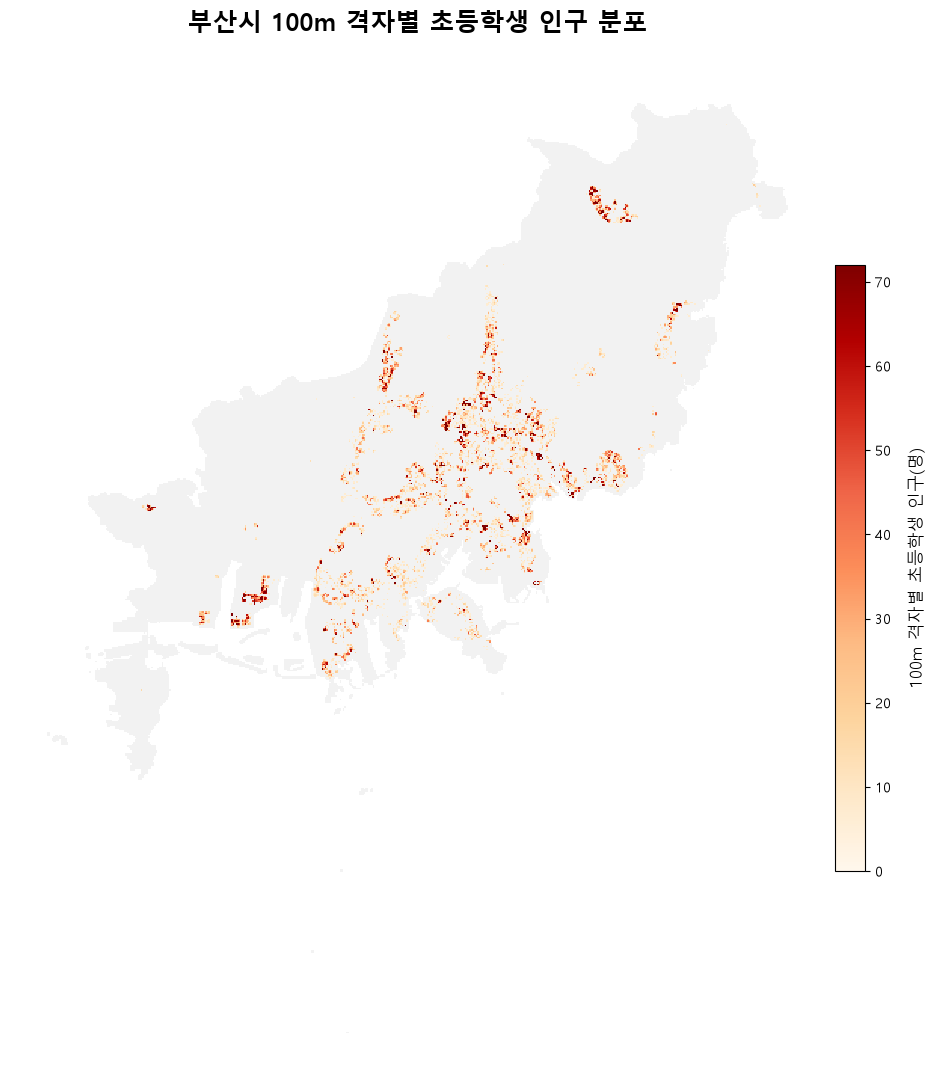

전체 격자 수: 81,849개
초등학생 인구가 있는 격자 수: 5,539개
격자별 최소 인구: 6명
격자별 최대 인구: 483명
지도 저장 위치: outputs\부산_100m격자_초등학생인구_연속형히트맵.png


In [11]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 초등학생 인구가 들어 있는 열
POP_COL = "val"

# 결과 저장 폴더
OUTPUT_DIR = "outputs"
OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "부산_100m격자_초등학생인구_연속형히트맵.png"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)


if POP_COL not in gdf.columns:
    raise KeyError(
        f"'{POP_COL}' 열이 없습니다.\n"
        f"현재 열 목록: {gdf.columns.tolist()}"
    )

plot_gdf = gdf.copy()

# 인구 열을 숫자형으로 변환
plot_gdf[POP_COL] = pd.to_numeric(
    plot_gdf[POP_COL],
    errors="coerce"
).fillna(0)

# 잘못된 음수 값이 있다면 0으로 처리
plot_gdf.loc[plot_gdf[POP_COL] < 0, POP_COL] = 0

# 초등학생 인구가 존재하는 격자만 표시
population_gdf = plot_gdf[
    plot_gdf[POP_COL] > 0
].copy()

if population_gdf.empty:
    raise ValueError("초등학생 인구가 1명 이상인 격자가 없습니다.")


# 색상 기준
## 상위 5%는 가장 진하게 표현
vmax = population_gdf[POP_COL].quantile(0.95)

norm = Normalize(
    vmin=0,
    vmax=vmax,
    clip=True
)

cmap = plt.get_cmap("OrRd")


fig, ax = plt.subplots(
    figsize=(11, 11)
)

plot_gdf.plot(
    ax=ax,
    color="#f2f2f2",
    edgecolor="none"
)

population_gdf.plot(
    ax=ax,
    column=POP_COL,
    cmap=cmap,
    norm=norm,
    edgecolor="none",
    linewidth=0
)


sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.03,
    pad=0.01,
    shrink=0.72
)

cbar.set_label(
    "100m 격자별 초등학생 인구(명)",
    fontsize=12,
    labelpad=12
)

cbar.ax.tick_params(
    labelsize=10
)


ax.set_title(
    "부산시 100m 격자별 초등학생 인구 분포",
    fontsize=18,
    fontweight="bold",
    pad=18
)


ax.set_axis_off()

plt.tight_layout()



plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"전체 격자 수: {len(plot_gdf):,}개")
print(f"초등학생 인구가 있는 격자 수: {len(population_gdf):,}개")
print(f"격자별 최소 인구: {population_gdf[POP_COL].min():,.0f}명")
print(f"격자별 최대 인구: {population_gdf[POP_COL].max():,.0f}명")
print(f"지도 저장 위치: {OUTPUT_FILE}")

# 초등학생 인구 100m 격자 지도 + 다함께돌봄센터

In [ ]:
# =========================
# 인구 격자 + 다함께돌봄센터
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

center_df = pd.read_csv("data/다함께돌봄센터_현황.csv", encoding="utf-8-sig")

# lon, lat 숫자형으로 변환
center_df["lon"] = pd.to_numeric(center_df["lon"], errors="coerce")
center_df["lat"] = pd.to_numeric(center_df["lat"], errors="coerce")

# 좌표 있는 것만 사용
center_ok = center_df.dropna(subset=["lon", "lat"]).copy()

print("전체 센터 수:", len(center_df))
print("점 찍을 센터 수:", len(center_ok))

# 점 데이터 GeoDataFrame 만들기
center_gdf = gpd.GeoDataFrame(
    center_ok,
    geometry=gpd.points_from_xy(center_ok["lon"], center_ok["lat"]),
    crs="EPSG:4326"
)

# 격자 지도 gdf와 좌표계 맞추기
center_gdf = center_gdf.to_crs(gdf.crs)

print("gdf 좌표계:", gdf.crs)
print("center_gdf 좌표계:", center_gdf.crs)
print("center_gdf 범위:", center_gdf.total_bounds)

# 지도 만들자
fig2, ax2 = plt.subplots(figsize=(10, 10))

# 결측값 / 통계 없음
gdf[gdf["pop_class"].isna()].plot(
    ax=ax2,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1
)

# 인구 구간별 색상 적용
for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax2,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.47
        )

# 새 지도2 위에 돌봄센터 점 찍기
center_gdf.plot(
    ax=ax2,
    color="#54278F",
    markersize=5,
    marker="o",
    zorder=10
)

# 범례 만들기
legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.47,
        label=label
    )
    for label in labels
]

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="black",
    markerfacecolor="#54278F",
    markersize=3,
    linestyle="None",
    label="다함께돌봄센터"
)

legend_handles.append(center_handle)

ax2.legend(
    handles=legend_handles,
    title="인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax2.set_title("부산 초등학생 100m 격자 + 다함께돌봄센터", fontsize=14)
ax2.set_axis_off()

plt.tight_layout()
#fig2.savefig("초등학생인구_다함께돌봄센터.png", dpi=300, bbox_inches="tight", facecolor="white") #이미지 저장용
plt.show()

# 초등학생 인구 100m 격자 지도 + 들락날락

In [ ]:
# =========================
# 초등학생 100m 인구 격자지도 + 들락날락
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dlnl_df = pd.read_csv("data/busan_dlnl_homepage_102_coord.csv", encoding="utf-8-sig")


dlnl_df["위도"] = pd.to_numeric(dlnl_df["위도"], errors="coerce")
dlnl_df["경도"] = pd.to_numeric(dlnl_df["경도"], errors="coerce")


dlnl_ok = dlnl_df.dropna(subset=["위도", "경도"]).copy()

print("전체 들락날락 수:", len(dlnl_df))
print("점 찍을 수:", len(dlnl_ok))


dlnl_gdf = gpd.GeoDataFrame(
    dlnl_ok,
    geometry=gpd.points_from_xy(dlnl_ok["경도"], dlnl_ok["위도"]),
    crs="EPSG:4326"
)


dlnl_gdf = dlnl_gdf.to_crs(gdf.crs)

print("gdf 좌표계:", gdf.crs)
print("dlnl_gdf 좌표계:", dlnl_gdf.crs)
print("gdf 범위:", gdf.total_bounds)
print("dlnl_gdf 범위:", dlnl_gdf.total_bounds)

fig3, ax3 = plt.subplots(figsize=(10, 10))


gdf[gdf["pop_class"].isna()].plot(
    ax=ax3,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax3,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax3,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)


minx, miny, maxx, maxy = gdf.total_bounds
ax3.set_xlim(minx, maxx)
ax3.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

legend_handles.append(dlnl_handle)

ax3.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax3.set_title("부산 초등학생 100m 격자와 들락날락 분포", fontsize=14)
ax3.set_axis_off()

plt.tight_layout()
#fig3.savefig("초등학생인구_들락날락.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 들락날락 + 다함께 돌봄센터

In [ ]:
# =========================
# 초등학생 100m 인구 격자지도 + 들락날락 + 다함께돌봄센터
# =========================

fig4, ax4 = plt.subplots(figsize=(10, 10))

gdf[gdf["pop_class"].isna()].plot(
    ax=ax4,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax4,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax4,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)

center_gdf.plot(
    ax=ax4,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=11,
    label="다함께돌봄센터"
)

minx, miny, maxx, maxy = gdf.total_bounds
ax4.set_xlim(minx, maxx)
ax4.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="white",
    markerfacecolor="#54278F",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="다함께돌봄센터"
)

legend_handles.append(dlnl_handle)
legend_handles.append(center_handle)

ax4.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax4.set_title("부산 초등학생 100m 격자 + 들락날락·다함께돌봄센터 분포", fontsize=14)
ax4.set_axis_off()

plt.tight_layout()
#fig4.savefig("초등학생인구_들락날락_다함께돌봄센터.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 다함께돌봄센터 + 들락날락 + 지역아동센터

In [ ]:
# =========================
# + 지역아동센터
# =========================

local_df = pd.read_csv("data/지역아동센터_시설현황.csv", encoding="utf-8-sig")

print(local_df.columns)
print(local_df.head())

local_df["lon"] = pd.to_numeric(local_df["lon"], errors="coerce")
local_df["lat"] = pd.to_numeric(local_df["lat"], errors="coerce")

local_ok = local_df.dropna(subset=["lon", "lat"]).copy()

print("지역아동센터 전체 수:", len(local_df))
print("점 찍을 수:", len(local_ok))

local_gdf = gpd.GeoDataFrame(
    local_ok,
    geometry=gpd.points_from_xy(local_ok["lon"], local_ok["lat"]),
    crs="EPSG:4326"
)

local_gdf = local_gdf.to_crs(gdf.crs)

print("local_gdf 범위:", local_gdf.total_bounds)

fig5, ax5 = plt.subplots(figsize=(10, 10))

gdf[gdf["pop_class"].isna()].plot(
    ax=ax5,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax5,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax5,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)

center_gdf.plot(
    ax=ax5,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=11,
    label="다함께돌봄센터"
)

local_gdf.plot(
    ax=ax5,
    color="#0E7CFF",
    markersize=4.5,
    linewidth=0.5,
    marker="s",
    zorder=12,
    label="지역아동센터"
)

minx, miny, maxx, maxy = gdf.total_bounds
ax4.set_xlim(minx, maxx)
ax4.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="white",
    markerfacecolor="#54278F",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="다함께돌봄센터"
)

local_handle = plt.Line2D(
    [],
    [],
    marker="s",
    color="white",
    markerfacecolor="#0E7CFF",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="지역아동센터"
)

legend_handles.append(dlnl_handle)
legend_handles.append(center_handle)
legend_handles.append(local_handle)

ax5.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax5.set_title("부산 초등학생 100m 격자 + 들락날락·다함께돌봄센터·지역아동센터 분포", fontsize=14)
ax5.set_axis_off()

plt.tight_layout()
#fig5.savefig("초등학생인구_들락날락_다함께돌봄센터_지역아동센터.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 접근성 계산

In [ ]:
!pip install -q networkx scipy tqdm

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.spatial import cKDTree
from shapely.geometry import LineString, MultiLineString
from tqdm.auto import tqdm

## 1.도로망 불러오기

In [ ]:
road_path = "data/도로중심선/N3L_A0020000_26.shp"

roads = gpd.read_file(road_path)

print("도로망 개수:", len(roads))
print("도로망 좌표계:", roads.crs)
print("격자 좌표계:", gdf.crs)
print(roads.columns)

## 2.부산 도로만 자르기

In [ ]:
minx, miny, maxx, maxy = gdf.total_bounds

# 1km 정도 여유
buffer = 1000

roads = roads.cx[
    minx-buffer:maxx+buffer,
    miny-buffer:maxy+buffer
].copy()

roads = roads[roads.geometry.notna()].copy()
roads = roads[~roads.geometry.is_empty].copy()

print("부산 주변 도로망 개수:", len(roads))

## 3.도로망 LineString → networkx 그래프
* 도로 좌표점 = 노드

* 좌표점 사이 도로 조각 = 엣지

* 도로 조각 길이 = weight

In [ ]:
def iter_line_geoms(geom):
    if geom is None or geom.is_empty:
        return

    if geom.geom_type == "LineString":
        yield geom

    elif geom.geom_type == "MultiLineString":
        for part in geom.geoms:
            yield part

def node_key(x, y, ndigits=3):
    # 좌표 소수점 3자리까지 반올림
    # 단위가 m라서 0.001m 수준
    return (round(float(x), ndigits), round(float(y), ndigits))

G = nx.Graph()

for geom in tqdm(roads.geometry, desc="도로망 그래프 생성"):
    for line in iter_line_geoms(geom):
        coords = list(line.coords)

        for a, b in zip(coords[:-1], coords[1:]):
            x1, y1 = a[0], a[1]
            x2, y2 = b[0], b[1]

            u = node_key(x1, y1)
            v = node_key(x2, y2)

            dist = math.hypot(u[0] - v[0], u[1] - v[1])

            if dist > 0:
                G.add_edge(u, v, weight=dist)

print("노드 수:", G.number_of_nodes())
print("엣지 수:", G.number_of_edges())

## 4.수요지점: 초등학생 인구가 있는 격자 중심점

In [ ]:
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce")

demand_gdf = gdf[gdf[pop_col].notna() & (gdf[pop_col] > 0)].copy()

demand_gdf["orig_index"] = demand_gdf.index
demand_gdf["demand_id"] = range(len(demand_gdf))

# 격자 중심점
demand_gdf["geometry"] = demand_gdf.geometry.centroid

print("전체 격자 수:", len(gdf))
print("수요 격자 수:", len(demand_gdf))
print(demand_gdf[[pop_col]].describe())

## 5.공급지점: 시설수 기준

In [ ]:
facility_layers = []

# 들락날락
tmp = dlnl_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "들락날락"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

# 다함께돌봄센터
tmp = center_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "다함께돌봄센터"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

# 지역아동센터
tmp = local_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "지역아동센터"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

facility_gdf = gpd.GeoDataFrame(
    pd.concat(facility_layers, ignore_index=True),
    crs=gdf.crs
)

facility_gdf = facility_gdf[facility_gdf.geometry.notna()].copy()
facility_gdf = facility_gdf[~facility_gdf.geometry.is_empty].copy()
facility_gdf["facility_id"] = range(len(facility_gdf))

print("전체 공급시설 수:", len(facility_gdf))
print(facility_gdf["facility_type"].value_counts())

## 6.가장 가까운 도로망 노드에 스냅

좌표값 기준

In [ ]:
nodes = list(G.nodes())
node_xy = np.array(nodes)

tree = cKDTree(node_xy)

def snap_points_to_nodes(point_gdf):
    pts = np.array([(geom.x, geom.y) for geom in point_gdf.geometry])
    dist, idx = tree.query(pts, k=1)

    snapped_nodes = [nodes[i] for i in idx]

    return snapped_nodes, dist

demand_gdf["nearest_node"], demand_gdf["snap_dist"] = snap_points_to_nodes(demand_gdf)
facility_gdf["nearest_node"], facility_gdf["snap_dist"] = snap_points_to_nodes(facility_gdf)

print("수요지점 스냅 거리 요약")
print(demand_gdf["snap_dist"].describe())

print("공급지점 스냅 거리 요약")
print(facility_gdf["snap_dist"].describe())

## 7.도로망에서 너무 멀리 떨어진 점 제외

도로망에서 200m보다 먼 시설 제외

In [ ]:
SNAP_MAX = 200

demand_gdf = demand_gdf[demand_gdf["snap_dist"] <= SNAP_MAX].copy()
facility_gdf = facility_gdf[facility_gdf["snap_dist"] <= SNAP_MAX].copy()

print("스냅 후 수요 격자 수:", len(demand_gdf))
print("스냅 후 공급시설 수:", len(facility_gdf))
print(facility_gdf["facility_type"].value_counts())

## 8.네트워크 거리 750m 이내 수요-공급 쌍 찾기
각 돌봄시설에서 도로망을 따라 750m 이내에 있는 초등학생 100m 격자

In [ ]:
THRESHOLD = 750  # 임계거리 750m

# 노드별 수요지점 목록 만들기
node_to_demands = {}

for _, row in demand_gdf.iterrows():
    node = row["nearest_node"]
    node_to_demands.setdefault(node, []).append(
        (
            row["demand_id"],
            row["orig_index"],
            float(row[pop_col]),
            float(row["snap_dist"])
        )
    )

pairs = []

for _, frow in tqdm(facility_gdf.iterrows(), total=len(facility_gdf), desc="시설별 750m 네트워크 탐색"):
    f_id = frow["facility_id"]
    f_node = frow["nearest_node"]
    f_snap = float(frow["snap_dist"])
    f_type = frow["facility_type"]

    # 스냅 거리까지 고려해서 조금 넉넉하게 탐색
    search_cutoff = THRESHOLD + (2 * SNAP_MAX)

    lengths = nx.single_source_dijkstra_path_length(
        G,
        source=f_node,
        cutoff=search_cutoff,
        weight="weight"
    )

    for node, net_dist in lengths.items():
        if node not in node_to_demands:
            continue

        for demand_id, orig_index, pop, d_snap in node_to_demands[node]:
            total_dist = net_dist + f_snap + d_snap

            if total_dist <= THRESHOLD:
                pairs.append({
                    "facility_id": f_id,
                    "facility_type": f_type,
                    "demand_id": demand_id,
                    "orig_index": orig_index,
                    "pop": pop,
                    "network_dist": total_dist
                })

pairs_df = pd.DataFrame(pairs)

print("750m 이내 수요-공급 쌍 개수:", len(pairs_df))
pairs_df.head()

## 9.거리 가중치 함수
d=0일 때 1,
d=d0일 때 0에 가까워지도록 조정

| 기호   | 의미                  |
| ---- | ------------------- |
| `d`  | 시설-수요 격자 사이 네트워크 거리 |
| `d0` | 임계거리, 여기서는 750m     |
| `w`  | 거리 가중치              |


In [ ]:
def gaussian_weight(d, d0=750):
    d = np.asarray(d)
    w = (np.exp(-0.5 * (d / d0) ** 2) - np.exp(-0.5)) / (1 - np.exp(-0.5))
    w = np.where((d <= d0) & (w > 0), w, 0)
    return w

pairs_df["w"] = gaussian_weight(pairs_df["network_dist"], THRESHOLD)

pairs_df[["network_dist", "w"]].describe()

## 10.시설수 기준 E2SFCA 계산

각 시설마다 공급량을 1로 봄

`R_j = 1 / 주변 가중 아동 인구`

`A_i = Σ(R_j × W_ij)`

| 기호     | 의미                   |
| ------ | -------------------- |
| `A_i`  | 격자 i의 접근성            |
| `R_j`  | 시설 j의 공급비            |
| `W_ij` | 격자 i와 시설 j 사이 거리 가중치 |

In [ ]:
# 각 시설 주변의 가중 수요 인구 합
pairs_df["weighted_pop"] = pairs_df["pop"] * pairs_df["w"]

denom_df = (
    pairs_df
    .groupby("facility_id", as_index=False)["weighted_pop"]
    .sum()
    .rename(columns={"weighted_pop": "weighted_demand"})
)

# 시설 정보와 결합
facility_supply = facility_gdf[["facility_id", "facility_type", "supply"]].copy()
facility_supply = facility_supply.merge(denom_df, on="facility_id", how="left")
facility_supply["weighted_demand"] = facility_supply["weighted_demand"].fillna(0)

# 공급비 R_j
facility_supply["R_j"] = np.where(
    facility_supply["weighted_demand"] > 0,
    facility_supply["supply"] / facility_supply["weighted_demand"],
    0
)

facility_supply.head()

In [ ]:
# 각 격자에서 도달 가능한 시설들의 공급비 합산
pairs_df = pairs_df.merge(
    facility_supply[["facility_id", "R_j"]],
    on="facility_id",
    how="left"
)

pairs_df["access_part"] = pairs_df["R_j"] * pairs_df["w"]

access_df = (
    pairs_df
    .groupby("orig_index", as_index=False)["access_part"]
    .sum()
    .rename(columns={"access_part": "access_e2sfca"})
)

access_df.head()

## 11.gdf에 접근성 붙이기

In [ ]:
# =========================
# 11.gdf에 접근성 붙이기 - 수정본
# =========================

# 초등학생 인구 격자
analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 기본값: 분석 제외는 NaN
gdf["access_e2sfca"] = np.nan

# 초등학생 인구가 있는 격자는 일단 접근성 0으로 둠
# 750m 안에 시설이 하나도 없는 곳도 분석 제외가 아니라 '접근성 0'이기 때문
gdf.loc[analysis_mask, "access_e2sfca"] = 0.0

# 계산된 접근성 값이 있는 격자는 덮어쓰기
gdf.loc[access_df["orig_index"], "access_e2sfca"] = access_df["access_e2sfca"].values

# 보기 쉽게 1000 곱하기
gdf["access_e2sfca_1000"] = gdf["access_e2sfca"] * 1000

print("초등학생 인구 있는 격자 수:", analysis_mask.sum())
print("접근성 0인 격자 수:", ((gdf["access_e2sfca"] == 0) & analysis_mask).sum())
print("접근성 양수인 격자 수:", ((gdf["access_e2sfca"] > 0) & analysis_mask).sum())

print(gdf.loc[analysis_mask, "access_e2sfca_1000"].describe())

## 12.접근성 지도

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="access_e2sfca_1000",
    cmap="YlGnBu",
    linewidth=0.05,
    edgecolor="#E6E6E6",
    legend=True,
    missing_kwds={
        "color": "#F2F2F2",
        "edgecolor": "#E6E6E6",
        "label": "계산 제외"
    }
)
'''
facility_gdf.plot(
    ax=ax,
    color="#E63946",
    markersize=5,
    marker="o",
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title(
    "부산 초등학생 100m 격자 시설수 기준 E2SFCA 접근성\n네트워크 거리 750m 기준",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
'''
fig.savefig(
    "부산_시설수기준_E2SFCA_접근성지도.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
'''
plt.show()

위의 접근성 지도가 색이 연하고 가독성이 떨어져서

상위 5% 이상 값들은 다 진한 색으로 처리해봄



In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 너무 큰 극단값 때문에 색이 연해지는 걸 막기 위해 95% 분위수를 최대색 기준으로 사용
vmax = gdf.loc[analysis_mask, "access_e2sfca_1000"].quantile(0.95)

gdf.plot(
    ax=ax,
    column="access_e2sfca_1000",
    cmap="YlGnBu",          # YlGnBu보다 더 진하고 직관적
    linewidth=0.03,
    edgecolor="#E6E6E6",
    legend=True,
    vmin=0,
    vmax=vmax,
    missing_kwds={
        "color": "#F2F2F2",
        "edgecolor": "#E6E6E6",
        "label": "초등학생 인구 없음 / 분석 제외"
    }
)
'''
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title(
    "부산 초등학생 100m 격자 시설 수 기준 E2SFCA 접근성\n도로망 거리 750m 기준",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
'''
fig.savefig(
    "부산_시설수기준_E2SFCA_접근성지도_진하게.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
'''
plt.show()

## 13.시설부족지역 기준
* 초등학생 인구가 있는 격자만 분석 대상으로 사용
* 고수요 기준: 초등학생 인구 상위 25%
* 저접근성 기준: E2SFCA 접근성 하위 25%

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 초등학생 인구가 있는 격자만 분석 대상으로 사용
analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 접근성은 이미 11번에서
# 초등학생 인구 있는 격자: 0 또는 양수
# 초등학생 인구 없는 격자: NaN
# 상태로 만들어졌다고 가정

# 분석용 컬럼
gdf["access_for_gap"] = gdf["access_e2sfca_1000"]

# 기준값 계산
pop_q75 = gdf.loc[analysis_mask, pop_col].quantile(0.75)
acc_q25 = gdf.loc[analysis_mask, "access_for_gap"].quantile(0.25)

print("초등학생 인구 상위 25% 기준:", pop_q75)
print("접근성 하위 25% 기준:", acc_q25)

In [ ]:

gdf["high_demand"] = False
gdf["low_access"] = False
gdf["shortage_area"] = False

gdf.loc[analysis_mask, "high_demand"] = gdf.loc[analysis_mask, pop_col] >= pop_q75
gdf.loc[analysis_mask, "low_access"] = gdf.loc[analysis_mask, "access_for_gap"] <= acc_q25

gdf.loc[analysis_mask, "shortage_area"] = (
    gdf.loc[analysis_mask, "high_demand"] &
    gdf.loc[analysis_mask, "low_access"]
)

print("분석 대상 격자 수:", analysis_mask.sum())
print("고수요 격자 수:", gdf["high_demand"].sum())
print("저접근성 격자 수:", gdf["low_access"].sum())
print("부족지역 격자 수:", gdf["shortage_area"].sum())

In [ ]:
gdf["gap_type"] = "분석 제외"

gdf.loc[analysis_mask & gdf["high_demand"] & gdf["low_access"], "gap_type"] = "고수요-저접근성"
gdf.loc[analysis_mask & gdf["high_demand"] & ~gdf["low_access"], "gap_type"] = "고수요-접근성양호"
gdf.loc[analysis_mask & ~gdf["high_demand"] & gdf["low_access"], "gap_type"] = "저수요-저접근성"
gdf.loc[analysis_mask & ~gdf["high_demand"] & ~gdf["low_access"], "gap_type"] = "저수요-접근성양호"

print(gdf["gap_type"].value_counts())

## 14.4유형 지도

In [ ]:
gap_colors = {
    "고수요-저접근성": "#D73027",     # 빨강
    "고수요-접근성양호": "#FDAE61",  # 주황
    "저수요-저접근성": "#ABDDA4",     # 연두
    "저수요-접근성양호": "#2B83BA",  # 파랑
    "분석 제외": "#F2F2F2"           # 회색
}

fig, ax = plt.subplots(figsize=(10, 10))

for typ in ["분석 제외", "저수요-접근성양호", "저수요-저접근성", "고수요-접근성양호", "고수요-저접근성"]:
    subset = gdf[gdf["gap_type"] == typ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=gap_colors[typ],
            edgecolor="#E6E6E6",
            linewidth=0.03,
            alpha=0.85 if typ != "분석 제외" else 0.35
        )
'''
# 시설 점 보조 표시
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(facecolor=gap_colors["고수요-저접근성"], edgecolor="#E6E6E6", label="고수요-저접근성"),
    mpatches.Patch(facecolor=gap_colors["고수요-접근성양호"], edgecolor="#E6E6E6", label="고수요-접근성양호"),
    mpatches.Patch(facecolor=gap_colors["저수요-저접근성"], edgecolor="#E6E6E6", label="저수요-저접근성"),
    mpatches.Patch(facecolor=gap_colors["저수요-접근성양호"], edgecolor="#E6E6E6", label="저수요-접근성양호"),
    mpatches.Patch(facecolor=gap_colors["분석 제외"], edgecolor="#E6E6E6", label="분석 제외")
]

ax.legend(
    handles=legend_handles,
    title="수요-접근성 유형",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title("부산 초등학생 돌봄시설 부족지역 유형 지도", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
fig.savefig("부산_돌봄시설_부족지역_4유형지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 15.고수요-저접근성 강조 지도

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    color="#F2F2F2",
    edgecolor="#E6E6E6",
    linewidth=0.03,
    alpha=0.5
)

gdf[gdf["shortage_area"]].plot(
    ax=ax,
    color="#D73027",
    edgecolor="#A50026",
    linewidth=0.08,
    alpha=0.9,
    label="부족지역"
)
'''
# 시설 점
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title(
    "부산 초등학생 돌봄시설 부족지역\n(초등학생 인구 상위 25% & 접근성 하위 25%)",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
fig.savefig("부산_돌봄시설_부족지역_강조지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()